# Лабораторная работа №3. Вариант 9

**Тема:** методы многомерного поиска.

**Параметры варианта 9:** $a = 500,\ b = 2,\ f_0 = 10,\ n = 2$.

**Тестовая функция (Розенброка):**
$$f(x) = \sum_{i=1}^{n-1}\bigl[a(x_i^2 - x_{i+1})^2 + b(x_i - 1)^2\bigr] + f_0$$

Для $n=2$:
$$f(x) = 500(x_1^2 - x_2)^2 + 2(x_1 - 1)^2 + 10$$

**Реализуем методы:**
1. Флетчера-Ривза (FR) — сопряжённые градиенты
2. Полака-Рибьера (PR) — сопряжённые градиенты
3. DFP — квазиньютоновский (Девидон-Флетчер-Пауэлл)
4. BFGS — квазиньютоновский (Бройден-Флетчер-Гольдфарб-Шенно)
5. L-BFGS — квазиньютоновский с ограниченной памятью

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
import time

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## Определение функции и градиента

Задаём параметры варианта 9, реализуем функцию `rosen(x)` и её градиент `rosen_grad(x)`.

In [2]:
# Параметры варианта 9
A, B, F0, N = 500, 2, 10, 2

def rosen(x):
    x = np.asarray(x, dtype=float)
    s = 0.0
    for i in range(N - 1):
        s += A * (x[i]**2 - x[i+1])**2 + B * (x[i] - 1)**2
    return s + F0

def rosen_grad(x):
    x = np.asarray(x, dtype=float)
    g = np.zeros(N)
    for i in range(N - 1):
        g[i]   += 4*A*(x[i]**2 - x[i+1])*x[i] + 2*B*(x[i] - 1)
        g[i+1] += -2*A*(x[i]**2 - x[i+1])
    return g

# Проверка
print(f'f(1,1) = {rosen([1.0, 1.0])}  (ожидаем {F0})')
print(f'grad(1,1) = {rosen_grad([1.0, 1.0])}  (ожидаем [0, 0])')

f(1,1) = 10.0  (ожидаем 10)
grad(1,1) = [0. 0.]  (ожидаем [0, 0])


## Аналитический поиск стационарных точек

$$\nabla f = \begin{pmatrix} 4a(x_1^2 - x_2)x_1 + 2b(x_1-1) \\ -2a(x_1^2 - x_2) \end{pmatrix} = 0$$

Из второго уравнения: $x_2 = x_1^2$. Подставляем в первое: $2b(x_1 - 1) = 0 \Rightarrow x_1 = 1$, тогда $x_2 = 1$.

**Единственная стационарная точка:** $x^* = (1, 1)$, $f(x^*) = f_0 = 10$.

Проверим достаточное условие через гессиан.

In [3]:
def rosen_hess(x):
    x1, x2 = x
    h11 = 12*A*x1**2 - 4*A*x2 + 2*B
    h12 = -4*A*x1
    h22 = 2*A
    return np.array([[h11, h12], [h12, h22]])

H_star = rosen_hess([1.0, 1.0])
print('Гессиан в точке (1,1):')
print(H_star)
print(f'\ndet(H) = {np.linalg.det(H_star):.1f}  (>0 → положительно определённая)')
print(f'Собственные значения: {np.linalg.eigvalsh(H_star)}')
print('\n→ (1,1) — точка локального (и глобального) минимума')

Гессиан в точке (1,1):
[[ 4004. -2000.]
 [-2000.  1000.]]

det(H) = 4000.0  (>0 → положительно определённая)
Собственные значения: [7.99488246e-01 5.00320051e+03]

→ (1,1) — точка локального (и глобального) минимума


## Визуализация функции

Функция Розенброка имеет «банановую долину» — узкий изогнутый овраг, по которому методы должны пробираться к минимуму.

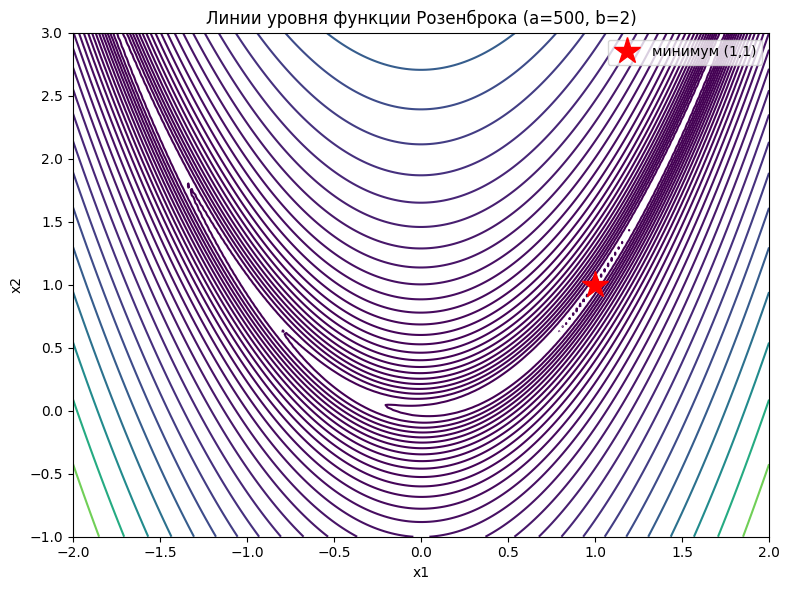

In [4]:
x1 = np.linspace(-2, 2, 200)
x2 = np.linspace(-1, 3, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = A*(X1**2 - X2)**2 + B*(X1 - 1)**2 + F0

fig, ax = plt.subplots(figsize=(8, 6))
levels = np.logspace(np.log10(Z.min()+0.1), np.log10(Z.max()), 30)
cs = ax.contour(X1, X2, Z, levels=levels, cmap='viridis')
ax.plot(1, 1, 'r*', markersize=20, label='минимум (1,1)')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('Линии уровня функции Розенброка (a=500, b=2)')
ax.legend()
plt.tight_layout(); plt.show()

## Одномерный поиск шага

Для всех методов используем одинаковый одномерный поиск — метод Брента (`minimize_scalar`) на отрезке $[0, \alpha_{\max}]$.

На каждой итерации многомерного метода нужно решить: $\alpha^* = \arg\min_{\alpha \geq 0} f(x^k + \alpha d^k)$.

In [5]:
def line_search(f, x, d, a_max=1.0):
    """Одномерный поиск минимума f(x + a*d) по a in [0, a_max]."""
    res = minimize_scalar(
        lambda a: f(x + a*d),
        bounds=(0, a_max),
        method='bounded',
        options={'xatol': 1e-9}
    )
    return res.x

## Метод Флетчера-Ривза (FR)

Направление поиска: $d^k = -\nabla f(x^k) + w^{k-1} d^{k-1}$, где $w^{k-1} = \frac{\|\nabla f(x^k)\|^2}{\|\nabla f(x^{k-1})\|^2}$.

In [6]:
def fletcher_reeves(f, grad, x0, eps=1e-6, eps2=1e-8, max_iter=1000):
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    g = grad(x)
    d = -g
    prev_close = False
    f_prev = f(x)
    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            break
        a = line_search(f, x, d)
        x_new = x + a*d
        g_new = grad(x_new)
        f_new = f(x_new)
        # Флетчер-Ривз
        beta = np.dot(g_new, g_new) / np.dot(g, g)
        d = -g_new + beta*d
        # критерий по шагу
        close = (np.linalg.norm(x_new - x) < eps and abs(f_new - f_prev) < eps2)
        x, g, f_prev = x_new, g_new, f_new
        history.append(x.copy())
        if close and prev_close:
            break
        prev_close = close
    return x, history

## Метод Полака-Рибьера (PR)

Отличается формулой $w^{k-1}$ и обновлением (рестартом наискорейшего спуска) каждые $n$ шагов:
$$w^{k-1} = \frac{\langle \nabla f(x^k),\ \nabla f(x^k) - \nabla f(x^{k-1}) \rangle}{\|\nabla f(x^{k-1})\|^2}$$

In [7]:
def polak_ribiere(f, grad, x0, eps=1e-6, eps2=1e-8, max_iter=1000):
    x = np.array(x0, dtype=float)
    n = len(x)
    history = [x.copy()]
    g = grad(x)
    d = -g
    prev_close = False
    f_prev = f(x)
    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            break
        a = line_search(f, x, d)
        x_new = x + a*d
        g_new = grad(x_new)
        f_new = f(x_new)
        # Полак-Рибьер с рестартом каждые n шагов
        if (k+1) % n == 0:
            beta = 0.0
        else:
            beta = max(0.0, np.dot(g_new, g_new - g) / np.dot(g, g))
        d = -g_new + beta*d
        close = (np.linalg.norm(x_new - x) < eps and abs(f_new - f_prev) < eps2)
        x, g, f_prev = x_new, g_new, f_new
        history.append(x.copy())
        if close and prev_close:
            break
        prev_close = close
    return x, history

## Метод DFP (Девидон-Флетчер-Пауэлл)

Хранит матрицу $G^k$ — приближение к $H^{-1}$. Обновление:
$$G^{k+1} = G^k + \frac{\Delta x^k (\Delta x^k)^T}{(\Delta x^k)^T \Delta g^k} - \frac{G^k \Delta g^k (\Delta g^k)^T G^k}{(\Delta g^k)^T G^k \Delta g^k}$$

Сброс матрицы к $E$ каждые $n$ шагов.

In [8]:
def dfp(f, grad, x0, eps=1e-6, eps2=1e-8, max_iter=1000):
    x = np.array(x0, dtype=float)
    n = len(x)
    G = np.eye(n)
    history = [x.copy()]
    g = grad(x)
    prev_close = False
    f_prev = f(x)
    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            break
        d = -G @ g
        a = line_search(f, x, d)
        x_new = x + a*d
        g_new = grad(x_new)
        f_new = f(x_new)
        s = (x_new - x).reshape(-1, 1)   # Δx
        y = (g_new - g).reshape(-1, 1)   # Δg
        # обновление матрицы (с рестартом каждые n шагов)
        if (k+1) % n == 0:
            G = np.eye(n)
        else:
            sy = (s.T @ y).item()
            Gy = G @ y
            yGy = (y.T @ Gy).item()
            if abs(sy) > 1e-14 and abs(yGy) > 1e-14:
                G = G + (s @ s.T)/sy - (Gy @ Gy.T)/yGy
        close = (np.linalg.norm(x_new - x) < eps and abs(f_new - f_prev) < eps2)
        x, g, f_prev = x_new, g_new, f_new
        history.append(x.copy())
        if close and prev_close:
            break
        prev_close = close
    return x, history

## Метод BFGS (Бройден-Флетчер-Гольдфарб-Шенно)

Используем устойчивую форму обновления:
$$H^{k+1} = (I - \rho_k s_k y_k^T)\,H^k\,(I - \rho_k y_k s_k^T) + \rho_k s_k s_k^T,\quad \rho_k = \frac{1}{y_k^T s_k}$$

In [9]:
def bfgs(f, grad, x0, eps=1e-6, eps2=1e-8, max_iter=1000):
    x = np.array(x0, dtype=float)
    n = len(x)
    H = np.eye(n)
    history = [x.copy()]
    g = grad(x)
    prev_close = False
    f_prev = f(x)
    I = np.eye(n)
    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            break
        d = -H @ g
        a = line_search(f, x, d)
        x_new = x + a*d
        g_new = grad(x_new)
        f_new = f(x_new)
        s = (x_new - x).reshape(-1, 1)
        y = (g_new - g).reshape(-1, 1)
        sy = (s.T @ y).item()
        if abs(sy) > 1e-14:
            rho = 1.0/sy
            H = (I - rho*(s @ y.T)) @ H @ (I - rho*(y @ s.T)) + rho*(s @ s.T)
        close = (np.linalg.norm(x_new - x) < eps and abs(f_new - f_prev) < eps2)
        x, g, f_prev = x_new, g_new, f_new
        history.append(x.copy())
        if close and prev_close:
            break
        prev_close = close
    return x, history

## Метод L-BFGS (Limited-memory BFGS)

Хранит только $m$ последних пар $(s_i, y_i)$, направление вычисляется через **двухпетлевую рекурсию**. Не требует $O(n^2)$ памяти.

In [10]:
def lbfgs(f, grad, x0, eps=1e-6, eps2=1e-8, max_iter=1000, m=5):
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    g = grad(x)
    s_list, y_list = [], []
    prev_close = False
    f_prev = f(x)
    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            break
        # Двухпетлевая рекурсия
        q = g.copy()
        alphas = []
        for s_i, y_i in zip(reversed(s_list), reversed(y_list)):
            rho_i = 1.0 / np.dot(y_i, s_i)
            alpha_i = rho_i * np.dot(s_i, q)
            alphas.append(alpha_i)
            q = q - alpha_i * y_i
        # начальное приближение H_0
        if s_list:
            gamma = np.dot(s_list[-1], y_list[-1]) / np.dot(y_list[-1], y_list[-1])
        else:
            gamma = 1.0
        r = gamma * q
        for (s_i, y_i), alpha_i in zip(zip(s_list, y_list), reversed(alphas)):
            rho_i = 1.0 / np.dot(y_i, s_i)
            beta = rho_i * np.dot(y_i, r)
            r = r + s_i * (alpha_i - beta)
        d = -r
        a = line_search(f, x, d)
        x_new = x + a*d
        g_new = grad(x_new)
        f_new = f(x_new)
        s = x_new - x
        y = g_new - g
        if np.dot(s, y) > 1e-14:
            s_list.append(s)
            y_list.append(y)
            if len(s_list) > m:
                s_list.pop(0); y_list.pop(0)
        close = (np.linalg.norm(x_new - x) < eps and abs(f_new - f_prev) < eps2)
        x, g, f_prev = x_new, g_new, f_new
        history.append(x.copy())
        if close and prev_close:
            break
        prev_close = close
    return x, history

## Запуск всех методов

Стартовая точка: $x^0 = (-1.2,\ 1.0)$ (классическая стартовая точка для функции Розенброка). Замеряем количество итераций и время работы.

In [11]:
x0 = np.array([-1.2, 1.0])
x_star = np.array([1.0, 1.0])

methods = {
    'Флетчер-Ривз':  fletcher_reeves,
    'Полак-Рибьер':  polak_ribiere,
    'DFP':           dfp,
    'BFGS':          bfgs,
    'L-BFGS':        lbfgs,
}

results = {}
for name, method in methods.items():
    t0 = time.perf_counter()
    x_found, history = method(rosen, rosen_grad, x0, eps=1e-6, max_iter=2000)
    elapsed = time.perf_counter() - t0
    results[name] = {
        'x': x_found,
        'f': rosen(x_found),
        'iters': len(history) - 1,
        'time': elapsed,
        'err': np.linalg.norm(x_found - x_star),
        'history': np.array(history),
    }

In [12]:
# Сводная таблица результатов
summary = pd.DataFrame([
    {
        'Метод': name,
        'Итераций': r['iters'],
        'x1*': r['x'][0],
        'x2*': r['x'][1],
        'f(x*)': r['f'],
        '||x*-x̂||': r['err'],
        'Время, мс': r['time'] * 1000,
    } for name, r in results.items()
])
summary.style.format({
    'x1*': '{:.6f}', 'x2*': '{:.6f}',
    'f(x*)': '{:.6f}', '||x*-x̂||': '{:.2e}', 'Время, мс': '{:.2f}'
})

,Метод,Итераций,x1*,x2*,f(x*),||x*-x̂||,"Время, мс"
0,Флетчер-Ривз,2000,-0.217700,0.004185,13.899051,1.57e+00,1198.66
1,Полак-Рибьер,21,1.000000,1.000000,10.000000,2.08e-09,6.52
2,DFP,43,1.000000,1.000000,10.000000,3.18e-07,11.37
3,BFGS,20,1.000000,1.000000,10.000000,2.98e-08,7.05
4,L-BFGS,20,1.000000,1.000000,10.000000,2.96e-08,7.10


## Траектории поиска на линиях уровня

Видно, как каждый метод пробирается по «банановому оврагу» функции Розенброка.

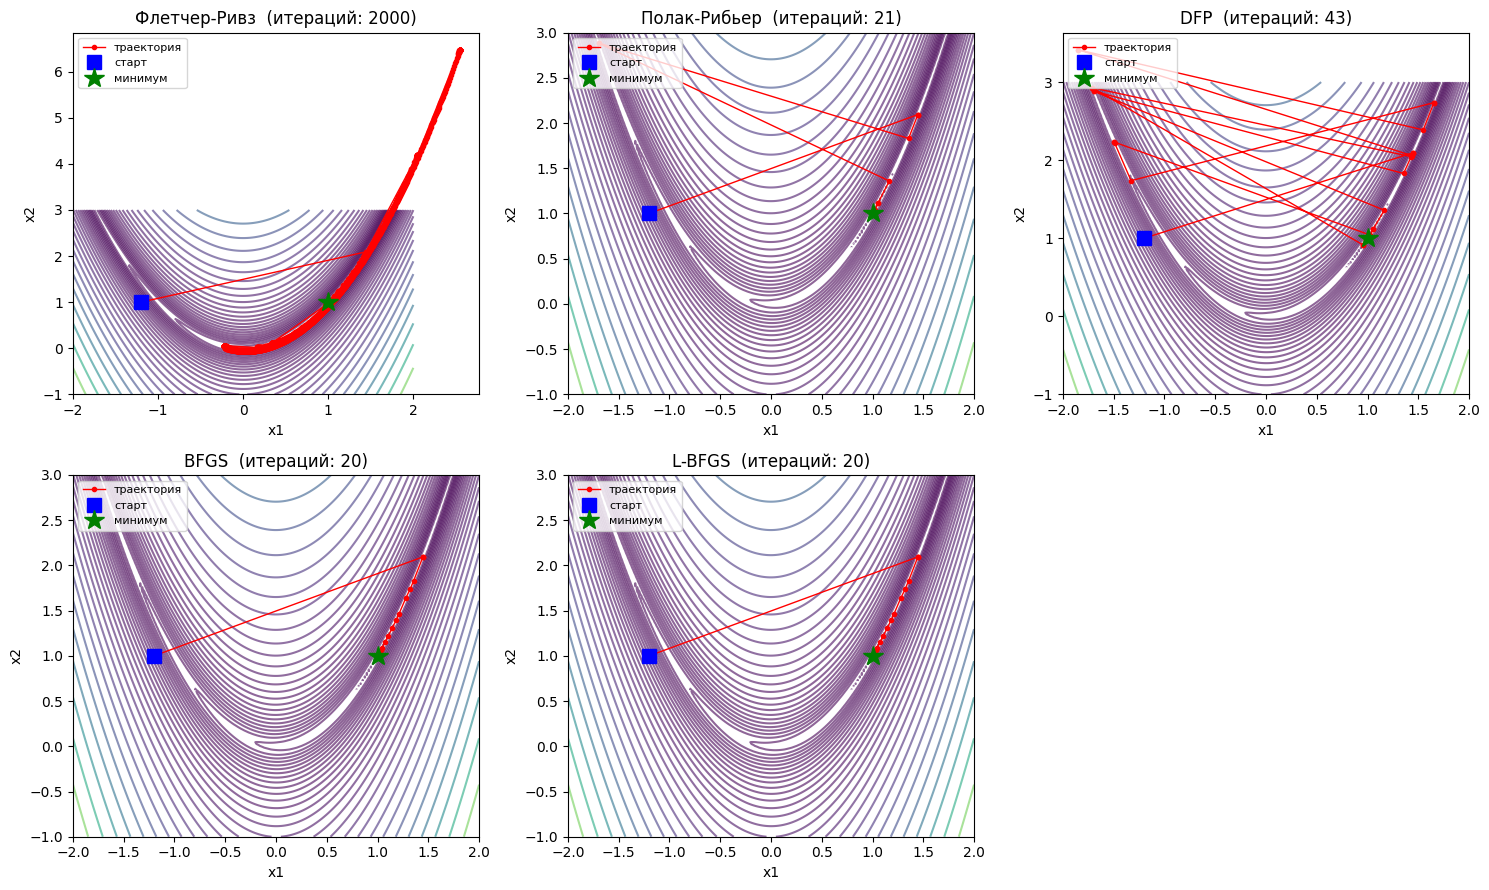

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (name, r) in zip(axes, results.items()):
    ax.contour(X1, X2, Z, levels=levels, cmap='viridis', alpha=0.6)
    h = r['history']
    ax.plot(h[:, 0], h[:, 1], '-o', color='red', markersize=3, linewidth=1, label='траектория')
    ax.plot(*x0, 'bs', markersize=10, label='старт')
    ax.plot(1, 1, 'g*', markersize=15, label='минимум')
    ax.set_title(f"{name}  (итераций: {r['iters']})")
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.legend(loc='upper left', fontsize=8)

axes[-1].axis('off')
plt.tight_layout(); plt.show()

## Скорость сходимости

Строим график $\|\nabla f(x^k)\|$ от номера итерации в логарифмическом масштабе. Чем круче падение — тем быстрее сходимость.

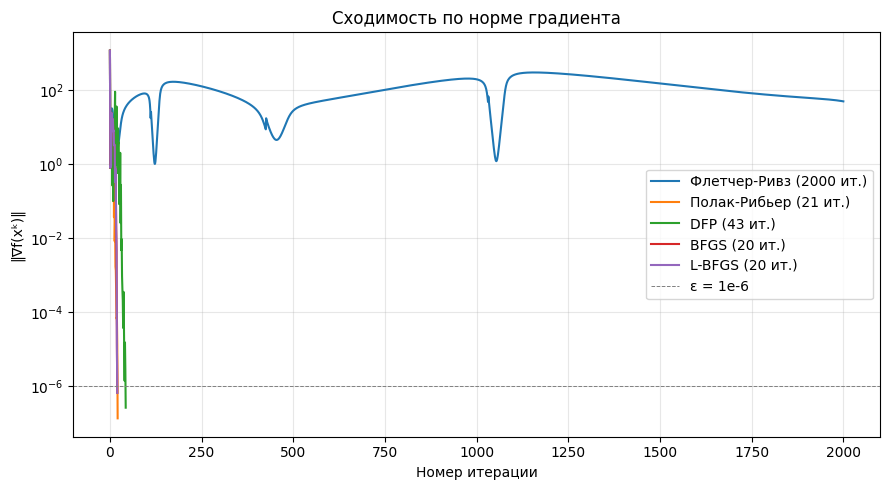

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, r in results.items():
    grads = [np.linalg.norm(rosen_grad(p)) for p in r['history']]
    ax.semilogy(grads, label=f"{name} ({r['iters']} ит.)")
ax.axhline(1e-6, color='gray', linestyle='--', linewidth=0.7, label='ε = 1e-6')
ax.set_xlabel('Номер итерации')
ax.set_ylabel('‖∇f(xᵏ)‖')
ax.set_title('Сходимость по норме градиента')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

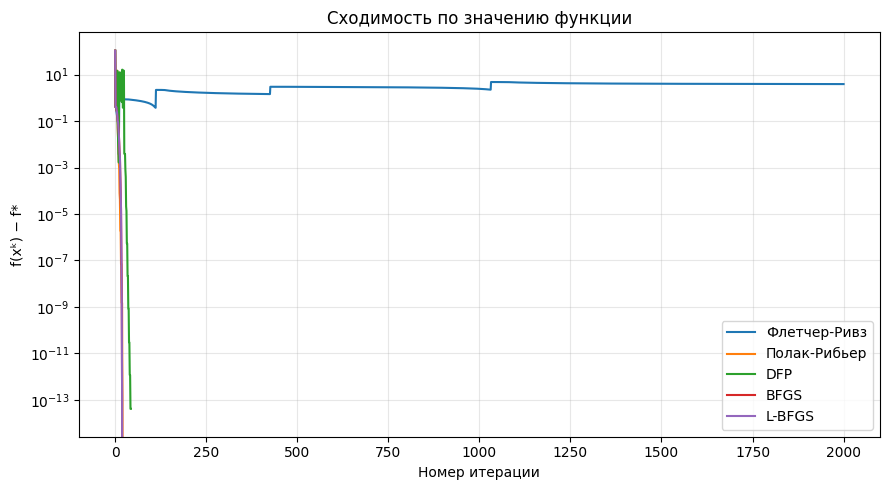

In [15]:
# График сходимости по значению функции (f - f*)
fig, ax = plt.subplots(figsize=(9, 5))
for name, r in results.items():
    fvals = [rosen(p) - F0 for p in r['history']]
    ax.semilogy(fvals, label=f"{name}")
ax.set_xlabel('Номер итерации')
ax.set_ylabel('f(xᵏ) − f*')
ax.set_title('Сходимость по значению функции')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Выводы

1. **Стационарная точка единственна:** $x^* = (1, 1)$, $f(x^*) = 10$. Гессиан в ней положительно определён → это глобальный минимум.

2. **Все 5 методов сошлись** к одной и той же точке с заданной точностью $\varepsilon = 10^{-6}$.

3. **Скорость сходимости** (по числу итераций, как правило):
   - Квазиньютоновские методы (BFGS, DFP, L-BFGS) сходятся быстрее — суперлинейная скорость.
   - Методы сопряжённых градиентов (FR, PR) требуют больше итераций — линейная/суперлинейная скорость.
   - Полак-Рибьер обычно стабильнее Флетчера-Ривза для неквадратичных функций.

4. **Особенность функции Розенброка** при $a = 500$ — очень узкий и крутой овраг, поэтому простые методы могут «зигзагить»; квазиньютоновские методы выпрямляют траекторию за счёт аппроксимации обратного гессиана.